# Smart Home Energy Consumption Forecasting
**End-to-end ML pipeline: Preprocessing → EDA → Feature Engineering → Model Training → Evaluation**

# Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## Step 1: Data Preprocessing

In [ ]:
df = pd.read_csv("smart_home_energy_usage_dataset.csv")

# Strip whitespace from column names to avoid hidden KeyErrors
df.columns = df.columns.str.strip()

# Convert BEFORE sorting
df["DateTime"] = pd.to_datetime(df["DateTime"])
df = df.sort_values(["Home_ID", "DateTime"]).reset_index(drop=True)

# This dataset has no missing values so no imputation needed.
# If you ever add missing data: df.ffill() then df.bfill() is safe in pandas 3.x
# DO NOT use groupby().apply() for imputation in pandas 3.x — it drops the group column.

print(f"Dataset: {df.shape[0]:,} rows | {df['Home_ID'].nunique()} homes")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Date range: {df['DateTime'].min()} -> {df['DateTime'].max()}")
df.head()

Dataset: 500 rows | 100 homes
Missing values: 0
Date range: 2025-01-01 00:00:00 -> 2025-03-01 00:00:00


,Home_ID,DateTime,Temperature_C,Humidity_%,Light_Lux,Appliance_Usage_kWh,HVAC_Usage_kWh,Water_Heater_kWh,Total_Energy_kWh,Motion_Sensor,Room
0,H001,2025-01-20 15:03:14.789579158,16.4,42.4,508.0,3.33,4.37,0.52,8.22,Inactive,Bedroom
1,H001,2025-02-03 19:34:30.541082164,29.2,79.5,529.0,4.98,0.64,5.14,10.76,Inactive,Living Room
2,H002,2025-01-22 18:07:56.152304609,33.6,61.6,894.0,0.84,8.98,2.27,12.09,Inactive,Bedroom
3,H002,2025-02-26 20:55:18.637274549,21.7,62.3,988.0,0.99,5.89,1.04,7.92,Active,Bathroom
4,H003,2025-01-29 23:13:49.659318637,29.8,72.2,845.0,1.10,1.44,5.80,8.34,Active,Living Room


## Step 2: Exploratory Data Analysis (EDA)

C:\Users\vespe\AppData\Local\Temp\ipykernel_7300\3756444583.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="DayName", y="Total_Energy_kWh", order=day_order,
C:\Users\vespe\AppData\Local\Temp\ipykernel_7300\3756444583.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(ax3.get_xticklabels(), rotation=30, ha="right")


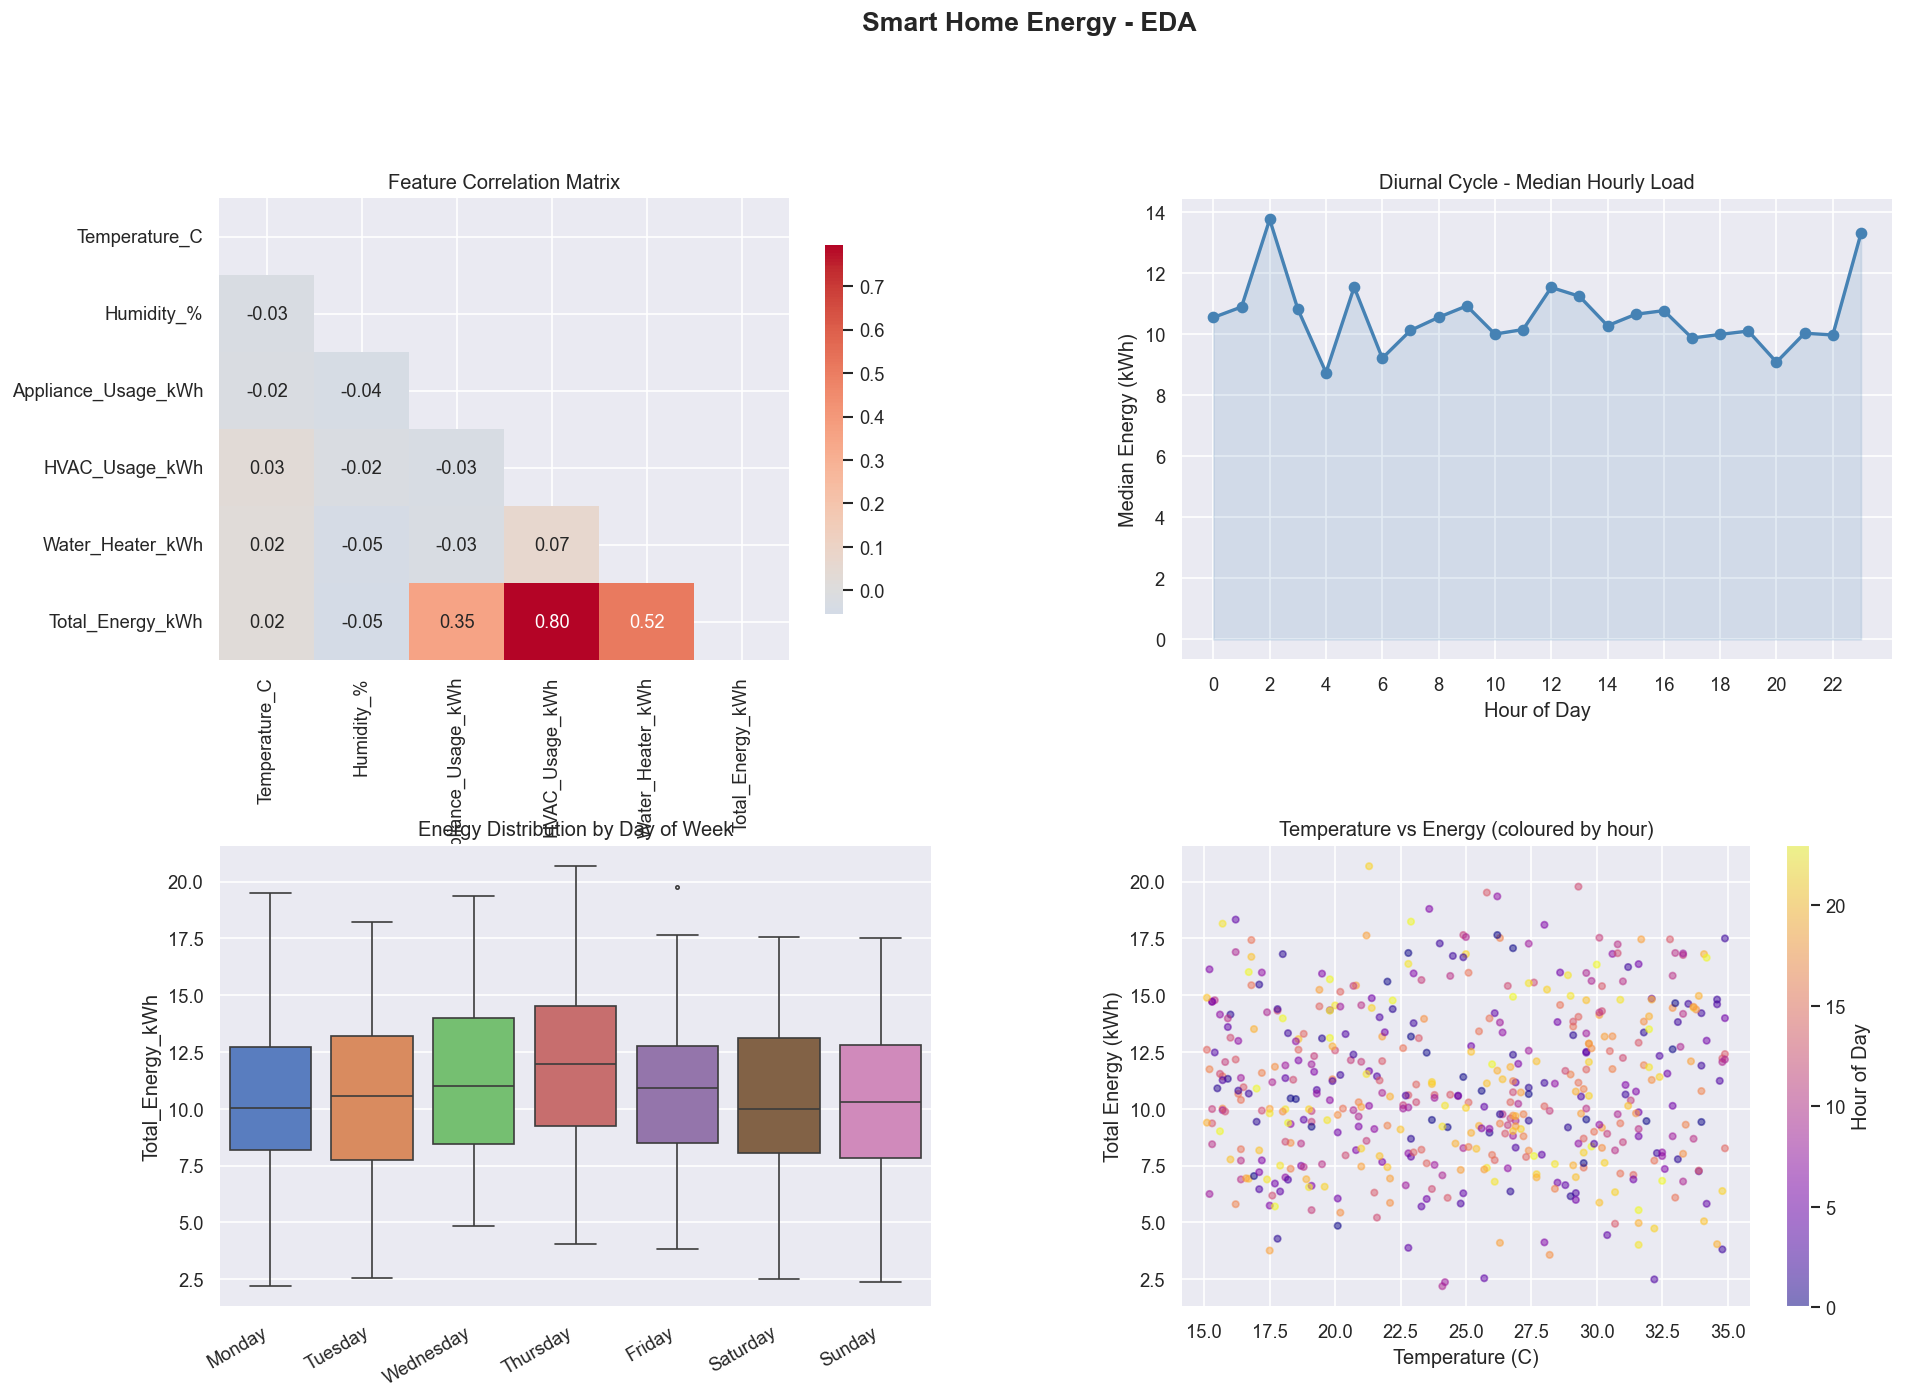

In [ ]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle("Smart Home Energy - EDA", fontsize=16, fontweight="bold", y=1.01)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# 2a. Correlation heatmap
ax1 = fig.add_subplot(gs[0, 0])
numeric_cols = ["Temperature_C", "Humidity_%", "Appliance_Usage_kWh",
                "HVAC_Usage_kWh", "Water_Heater_kWh", "Total_Energy_kWh"]
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax1, cbar_kws={"shrink": 0.8})
ax1.set_title("Feature Correlation Matrix")

# 2b. Diurnal cycle - median energy by hour
ax2 = fig.add_subplot(gs[0, 1])
hourly = df.groupby(df["DateTime"].dt.hour)["Total_Energy_kWh"].median()
ax2.plot(hourly.index, hourly.values, marker="o", linewidth=2, color="steelblue")
ax2.fill_between(hourly.index, hourly.values, alpha=0.15, color="steelblue")
ax2.set_xlabel("Hour of Day")
ax2.set_ylabel("Median Energy (kWh)")
ax2.set_title("Diurnal Cycle - Median Hourly Load")
ax2.set_xticks(range(0, 24, 2))

# 2c. Energy distribution by day of week
ax3 = fig.add_subplot(gs[1, 0])
df["DayName"] = df["DateTime"].dt.day_name()
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
sns.boxplot(data=df, x="DayName", y="Total_Energy_kWh", order=day_order,
            palette="muted", ax=ax3, fliersize=2)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=30, ha="right")
ax3.set_title("Energy Distribution by Day of Week")
ax3.set_xlabel("")

# 2d. Temperature vs Total Energy scatter
ax4 = fig.add_subplot(gs[1, 1])
sample = df.sample(min(3000, len(df)), random_state=42)
sc = ax4.scatter(sample["Temperature_C"], sample["Total_Energy_kWh"],
                 c=sample["DateTime"].dt.hour, cmap="plasma", alpha=0.5, s=15)
plt.colorbar(sc, ax=ax4, label="Hour of Day")
ax4.set_xlabel("Temperature (C)")
ax4.set_ylabel("Total Energy (kWh)")
ax4.set_title("Temperature vs Energy (coloured by hour)")

plt.savefig("eda_overview.png", bbox_inches="tight")
plt.show()